# Bước 5: Data Visualization
## UK Weather & Health: Weekly Deaths and Temperature (2016–2024)
---

## 5.1 Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Load dataset đã xử lý từ Notebook 2
df = pd.read_csv('uk_weather_health_weekly_CLEANED.csv',
                  parse_dates=['week_start_sat', 'week_start_mon', 'week_end'])
df = df.sort_values('week_start_mon').reset_index(drop=True)

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Các cột: {list(df.columns)}')
df.head(3)

Dataset: 442 rows × 15 columns
Các cột: ['week_start_sat', 'week_start_mon', 'week_end', 'deaths_total', 'tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC', 'year', 'month', 'week_of_year', 'quarter', 'season', 'temp_range_weekly', 'IsSurge', 'tasmax_mean_scaled', 'tasmax_max_scaled']


,week_start_sat,week_start_mon,week_end,deaths_total,tasmax_mean_weekly_degC,tasmax_max_weekly_degC,year,month,week_of_year,quarter,season,temp_range_weekly,IsSurge,tasmax_mean_scaled,tasmax_max_scaled
0,2016-01-02,2016-01-04,2016-01-08,13045.0,7.363329,8.839454,2016,1,1,1,Winter,1.476125,1,-1.140020,-1.227667
1,2016-01-09,2016-01-11,2016-01-15,11501.0,5.132909,7.135659,2016,1,2,1,Winter,2.002750,0,-1.565864,-1.539655
2,2016-01-16,2016-01-18,2016-01-22,11473.0,5.359014,10.233992,2016,1,3,1,Winter,4.874978,0,-1.522695,-0.972308


## 5.2 Heatmap — Ma trận tương quan giữa Nhiệt độ TB, Nhiệt độ cực đại & Tử vong

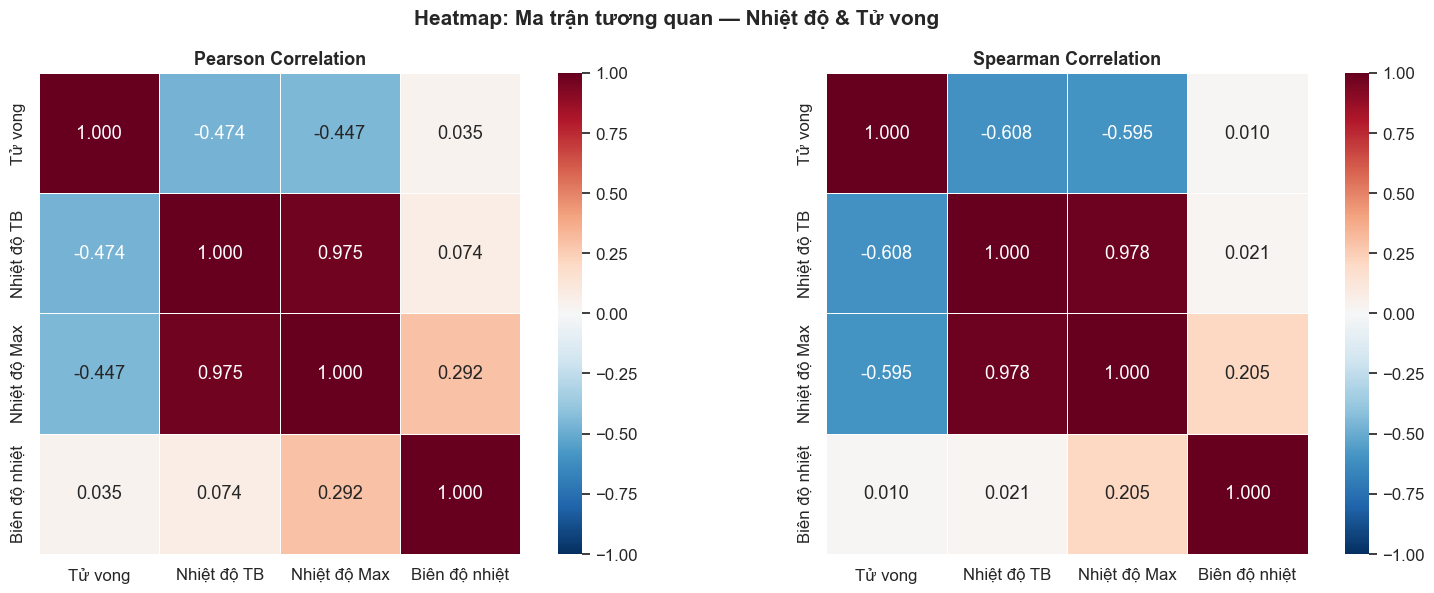

Pearson r (Tử vong vs Nhiệt độ TB) = -0.4740, p = 3.82e-26
→ Nghịch biến vừa phải: nhiệt độ tăng → tử vong giảm (do mùa đông tử vong cao)


In [2]:
corr_cols = ['deaths_total', 'tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC', 'temp_range_weekly']
corr_labels = ['Tử vong', 'Nhiệt độ TB', 'Nhiệt độ Max', 'Biên độ nhiệt']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson
pearson = df[corr_cols].corr(method='pearson')
pearson.index = corr_labels
pearson.columns = corr_labels
sns.heatmap(pearson, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Pearson Correlation', fontweight='bold', fontsize=13)

# Spearman
spearman = df[corr_cols].corr(method='spearman')
spearman.index = corr_labels
spearman.columns = corr_labels
sns.heatmap(spearman, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Spearman Correlation', fontweight='bold', fontsize=13)

plt.suptitle('Heatmap: Ma trận tương quan — Nhiệt độ & Tử vong', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(df['deaths_total'], df['tasmax_mean_weekly_degC'])
print(f'Pearson r (Tử vong vs Nhiệt độ TB) = {r:.4f}, p = {p:.2e}')
print('→ Nghịch biến vừa phải: nhiệt độ tăng → tử vong giảm (do mùa đông tử vong cao)')

## 5.3 Scatter Plot — Mối quan hệ `tasmax_mean` (X) vs `deaths_total` (Y)

Kỳ vọng: hình chữ **U** hoặc **J** — tử vong cao ở cả nhiệt độ rất thấp (mùa đông) và rất cao (nắng nóng).

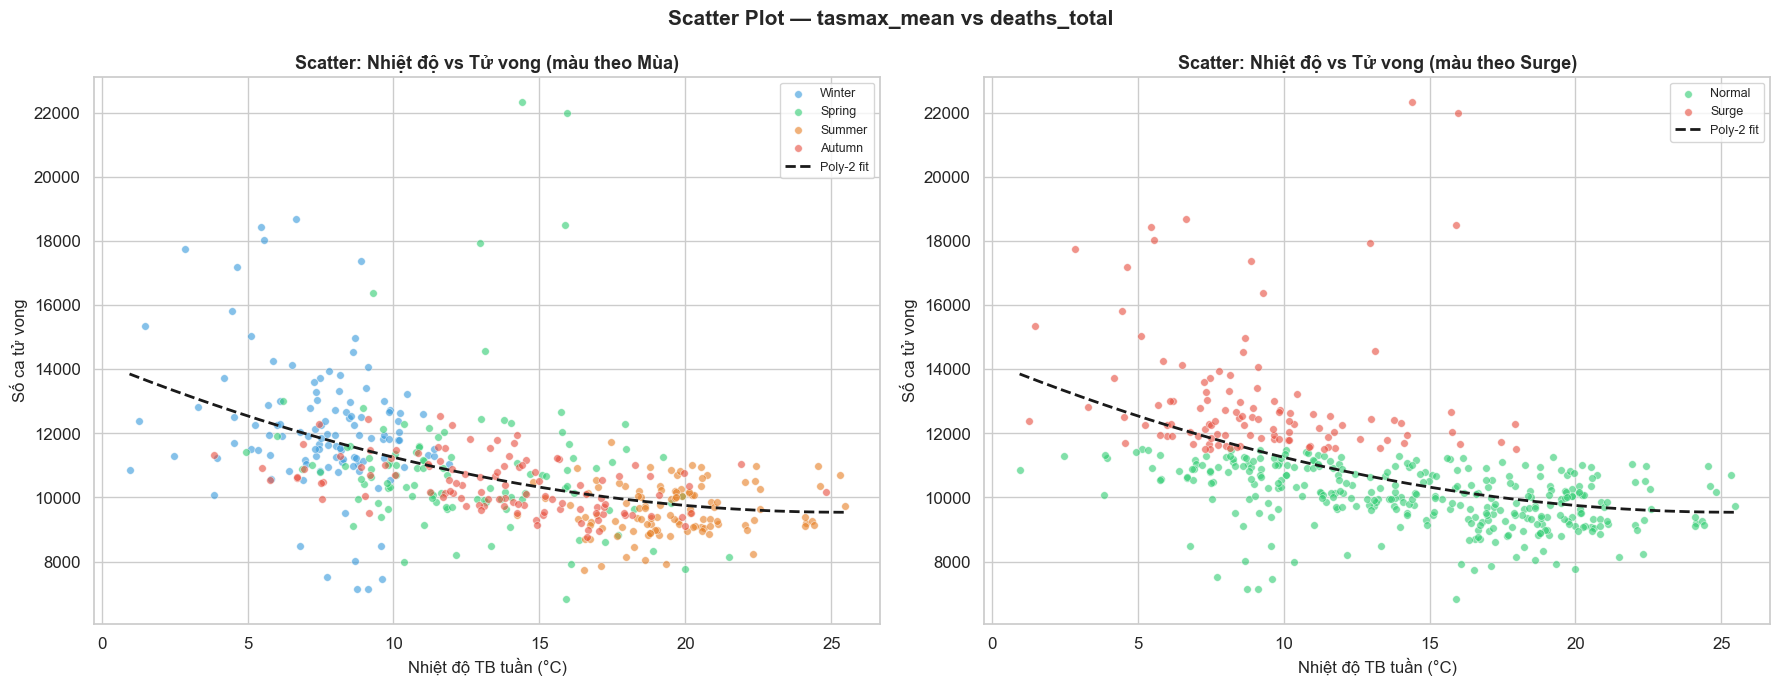

Hệ số poly bậc 2: y = 7.20x² + (-366.40)x + 14198
→ Đáy hình U tại ~25.4°C — xác nhận dạng chữ U/J


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter với màu theo mùa
season_colors = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#e67e22', 'Autumn': '#e74c3c'}
for season, color in season_colors.items():
    mask = df['season'] == season
    axes[0].scatter(df.loc[mask, 'tasmax_mean_weekly_degC'], df.loc[mask, 'deaths_total'],
                    c=color, label=season, alpha=0.6, s=30, edgecolor='white', linewidth=0.5)

# Đường hồi quy bậc 2 (polynomial) để thấy hình U/J
x = df['tasmax_mean_weekly_degC'].values
y = df['deaths_total'].values
coeffs = np.polyfit(x, y, 2)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = np.polyval(coeffs, x_fit)
axes[0].plot(x_fit, y_fit, 'k--', linewidth=2, label=f'Poly-2 fit')

axes[0].set_xlabel('Nhiệt độ TB tuần (°C)', fontsize=12)
axes[0].set_ylabel('Số ca tử vong', fontsize=12)
axes[0].set_title('Scatter: Nhiệt độ vs Tử vong (màu theo Mùa)', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=9)

# Scatter với màu theo IsSurge
surge_colors = {0: '#2ecc71', 1: '#e74c3c'}
surge_labels = {0: 'Normal', 1: 'Surge'}
for val, color in surge_colors.items():
    mask = df['IsSurge'] == val
    axes[1].scatter(df.loc[mask, 'tasmax_mean_weekly_degC'], df.loc[mask, 'deaths_total'],
                    c=color, label=surge_labels[val], alpha=0.6, s=30, edgecolor='white', linewidth=0.5)

axes[1].plot(x_fit, y_fit, 'k--', linewidth=2, label='Poly-2 fit')
axes[1].set_xlabel('Nhiệt độ TB tuần (°C)', fontsize=12)
axes[1].set_ylabel('Số ca tử vong', fontsize=12)
axes[1].set_title('Scatter: Nhiệt độ vs Tử vong (màu theo Surge)', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=9)

plt.suptitle('Scatter Plot — tasmax_mean vs deaths_total', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Hệ số poly bậc 2: y = {coeffs[0]:.2f}x² + ({coeffs[1]:.2f})x + {coeffs[2]:.0f}')
if coeffs[0] > 0:
    vertex_x = -coeffs[1] / (2 * coeffs[0])
    print(f'→ Đáy hình U tại ~{vertex_x:.1f}°C — xác nhận dạng chữ U/J')

## 5.4 Histogram — Phân bố số ca tử vong hàng tuần

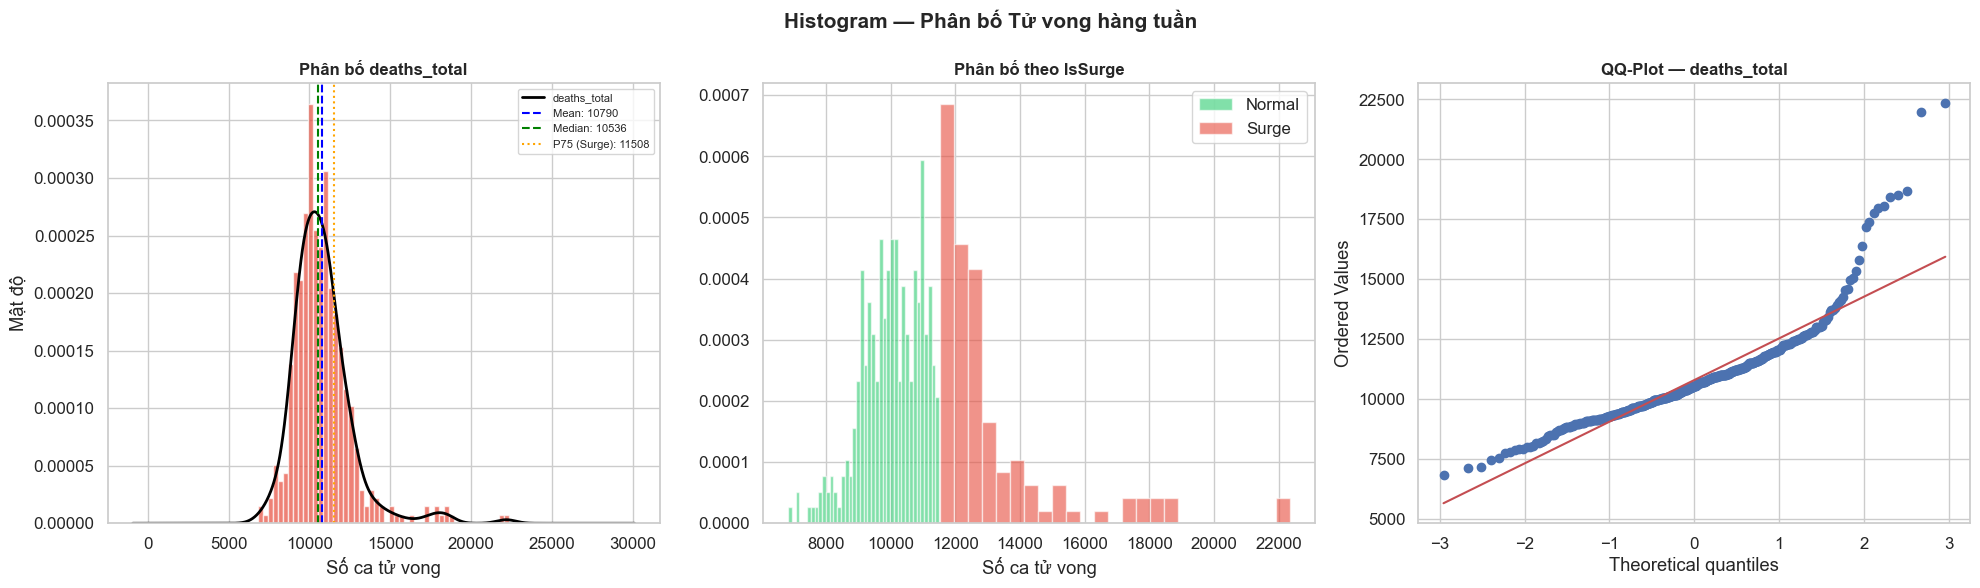

Skewness = 2.120 (lệch phải), Kurtosis = 8.379 (đuôi dày — do COVID outliers)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram chung
axes[0].hist(df['deaths_total'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.7, density=True)
df['deaths_total'].plot.kde(ax=axes[0], color='black', linewidth=2)
axes[0].axvline(df['deaths_total'].mean(), color='blue', linestyle='--',
                label=f'Mean: {df["deaths_total"].mean():.0f}')
axes[0].axvline(df['deaths_total'].median(), color='green', linestyle='--',
                label=f'Median: {df["deaths_total"].median():.0f}')
axes[0].axvline(df['deaths_total'].quantile(0.75), color='orange', linestyle=':',
                label=f'P75 (Surge): {df["deaths_total"].quantile(0.75):.0f}')
axes[0].set_title('Phân bố deaths_total', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Số ca tử vong')
axes[0].set_ylabel('Mật độ')
axes[0].legend(fontsize=8)

# Histogram theo IsSurge
axes[1].hist(df[df['IsSurge']==0]['deaths_total'], bins=40, color='#2ecc71', alpha=0.6,
             label='Normal', edgecolor='white', density=True)
axes[1].hist(df[df['IsSurge']==1]['deaths_total'], bins=25, color='#e74c3c', alpha=0.6,
             label='Surge', edgecolor='white', density=True)
axes[1].set_title('Phân bố theo IsSurge', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Số ca tử vong')
axes[1].legend()

# QQ-plot
stats.probplot(df['deaths_total'], dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot — deaths_total', fontweight='bold', fontsize=12)

plt.suptitle('Histogram — Phân bố Tử vong hàng tuần', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

skew = df['deaths_total'].skew()
kurt = df['deaths_total'].kurtosis()
print(f'Skewness = {skew:.3f} (lệch phải), Kurtosis = {kurt:.3f} (đuôi dày — do COVID outliers)')

## 5.5 Bar Chart — Tổng số tử vong theo từng năm (2016–2024)

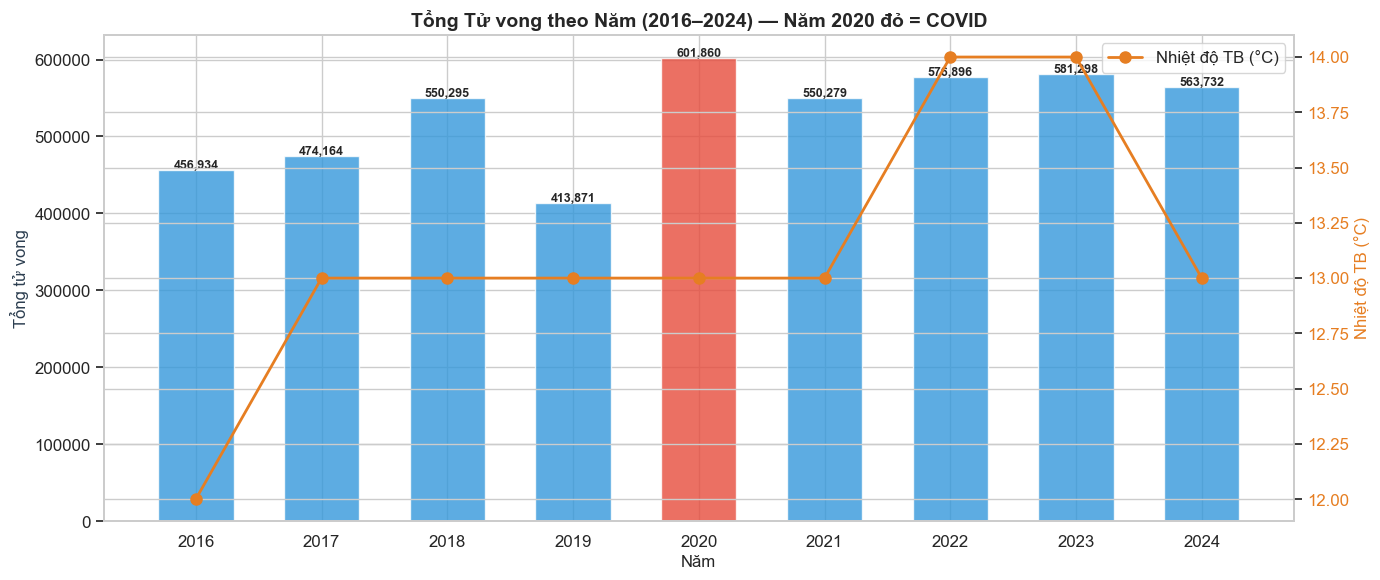

Tổng tử vong theo năm:
      total_deaths  weeks
year                     
2016      456934.0     45
2017      474164.0     46
2018      550295.0     53
2019      413871.0     41
2020      601860.0     52
2021      550279.0     49
2022      576896.0     52
2023      581298.0     52
2024      563732.0     52

→ Năm 2020 cao nhất: 601,860 ca (COVID-19)


In [5]:
yearly = df.groupby('year').agg(
    total_deaths=('deaths_total', 'sum'),
    avg_deaths=('deaths_total', 'mean'),
    avg_temp=('tasmax_mean_weekly_degC', 'mean'),
    weeks=('deaths_total', 'count')
).round(0)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar tổng tử vong
colors = ['#e74c3c' if y == 2020 else '#3498db' for y in yearly.index]
bars = ax1.bar(yearly.index, yearly['total_deaths'], color=colors, edgecolor='white',
               alpha=0.8, width=0.6)
ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Tổng tử vong', color='#2c3e50', fontsize=12)

# Ghi số lên bar
for bar, val in zip(bars, yearly['total_deaths']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'{val:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Line nhiệt độ TB
ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['avg_temp'], color='#e67e22', marker='o',
         linewidth=2, markersize=8, label='Nhiệt độ TB (°C)')
ax2.set_ylabel('Nhiệt độ TB (°C)', color='#e67e22', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e67e22')

ax1.set_xticks(yearly.index)
ax2.legend(loc='upper right')
plt.title('Tổng Tử vong theo Năm (2016–2024) — Năm 2020 đỏ = COVID', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('Tổng tử vong theo năm:')
print(yearly[['total_deaths', 'weeks']].to_string())
print(f'\n→ Năm 2020 cao nhất: {yearly.loc[2020, "total_deaths"]:,.0f} ca (COVID-19)')

## 5.6 Violin Plot — Phân bố tử vong giữa các mùa

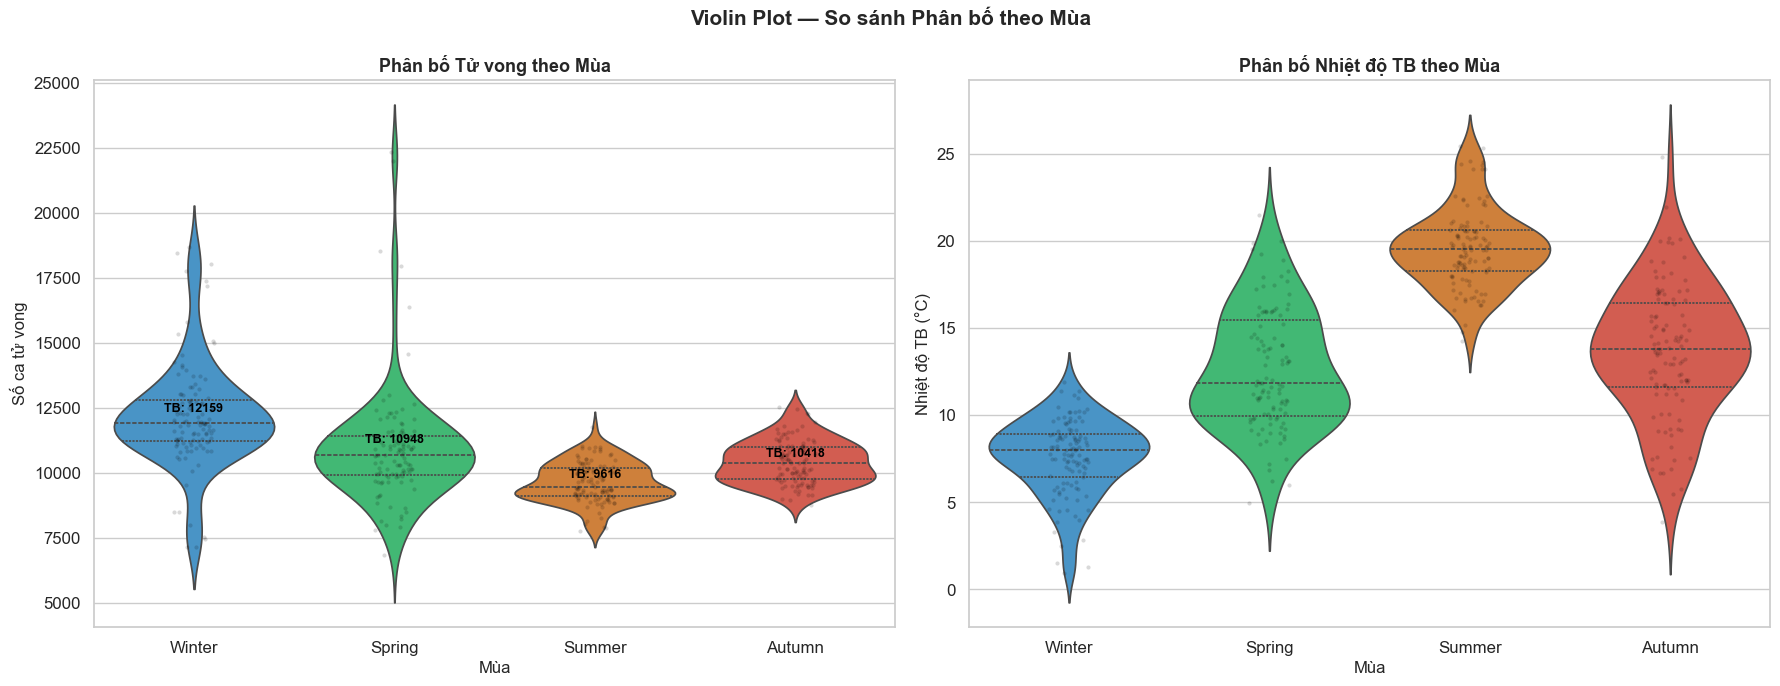

TB tử vong theo mùa:
  Winter  : Mean = 12159, Median = 11930, Std = 2064, n = 113
  Spring  : Mean = 10948, Median = 10687, Std = 2311, n = 107
  Summer  : Mean = 9616, Median = 9458, Std = 772, n = 111
  Autumn  : Mean = 10418, Median = 10388, Std = 833, n = 111


In [6]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_palette = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#e67e22', 'Autumn': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Violin plot tử vong
sns.violinplot(x='season', y='deaths_total', data=df, order=season_order,
               palette=season_palette, inner='quartile', ax=axes[0])
# Overlay với swarmplot (lấy mẫu nếu quá nhiều)
sns.stripplot(x='season', y='deaths_total', data=df, order=season_order,
              color='black', alpha=0.15, size=3, jitter=True, ax=axes[0])
axes[0].set_title('Phân bố Tử vong theo Mùa', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Mùa', fontsize=12)
axes[0].set_ylabel('Số ca tử vong', fontsize=12)

# Thêm mean annotations
means = df.groupby('season')['deaths_total'].mean()
for i, s in enumerate(season_order):
    axes[0].text(i, means[s] + 200, f'TB: {means[s]:.0f}', ha='center',
                 fontweight='bold', fontsize=9, color='black')

# Violin plot nhiệt độ
sns.violinplot(x='season', y='tasmax_mean_weekly_degC', data=df, order=season_order,
               palette=season_palette, inner='quartile', ax=axes[1])
sns.stripplot(x='season', y='tasmax_mean_weekly_degC', data=df, order=season_order,
              color='black', alpha=0.15, size=3, jitter=True, ax=axes[1])
axes[1].set_title('Phân bố Nhiệt độ TB theo Mùa', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Mùa', fontsize=12)
axes[1].set_ylabel('Nhiệt độ TB (°C)', fontsize=12)

plt.suptitle('Violin Plot — So sánh Phân bố theo Mùa', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('TB tử vong theo mùa:')
for s in season_order:
    m = df[df['season']==s]['deaths_total']
    print(f'  {s:8s}: Mean = {m.mean():.0f}, Median = {m.median():.0f}, Std = {m.std():.0f}, n = {len(m)}')

## 5.7 Line Plot — Diễn biến Nhiệt độ & Tử vong qua các năm (các đỉnh peaks)

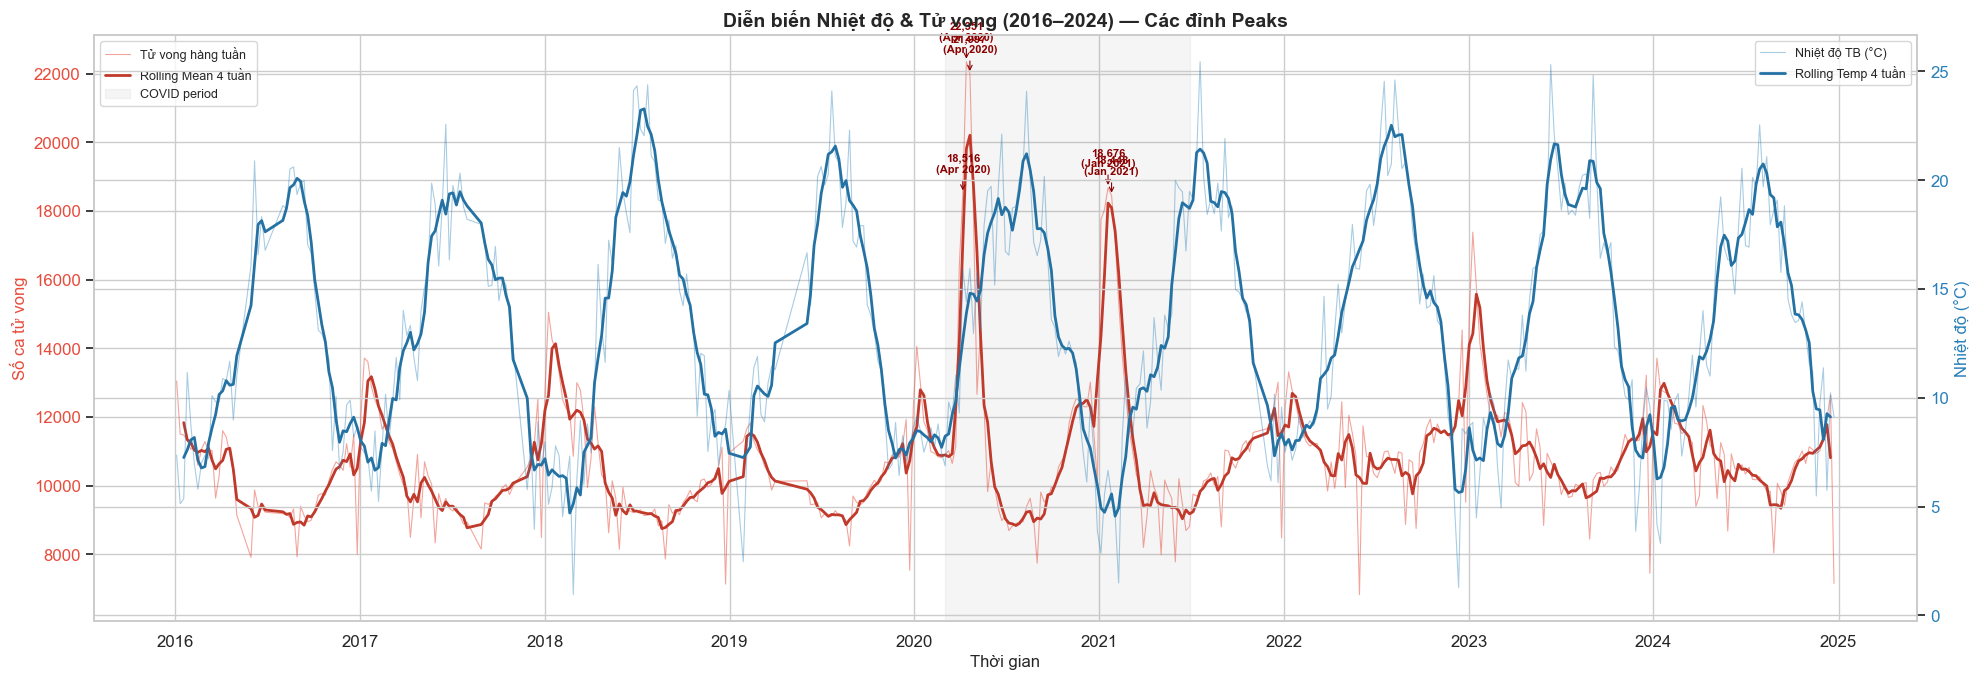

Top 5 tuần tử vong cao nhất:
week_start_mon  deaths_total  tasmax_mean_weekly_degC season
    2020-04-13       22351.0                14.414043 Spring
    2020-04-20       21997.0                15.959116 Spring
    2021-01-18       18676.0                 6.670256 Winter
    2020-04-06       18516.0                15.892410 Spring
    2021-01-25       18448.0                 5.451698 Winter


In [7]:
fig, ax1 = plt.subplots(figsize=(20, 7))

# Line tử vong
ax1.plot(df['week_start_mon'], df['deaths_total'], color='#e74c3c', alpha=0.5,
         linewidth=0.8, label='Tử vong hàng tuần')
# Rolling 4 tuần
rolling_4w = df['deaths_total'].rolling(4, center=True).mean()
ax1.plot(df['week_start_mon'], rolling_4w, color='#c0392b', linewidth=2,
         label='Rolling Mean 4 tuần')
ax1.set_ylabel('Số ca tử vong', color='#e74c3c', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#e74c3c')

# Line nhiệt độ
ax2 = ax1.twinx()
ax2.plot(df['week_start_mon'], df['tasmax_mean_weekly_degC'], color='#2980b9',
         alpha=0.4, linewidth=0.8, label='Nhiệt độ TB (°C)')
rolling_temp = df['tasmax_mean_weekly_degC'].rolling(4, center=True).mean()
ax2.plot(df['week_start_mon'], rolling_temp, color='#2471a3', linewidth=2,
         label='Rolling Temp 4 tuần')
ax2.set_ylabel('Nhiệt độ (°C)', color='#2980b9', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2980b9')

# Highlight COVID
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-30'),
            alpha=0.08, color='gray', label='COVID period')

# Đánh dấu các đỉnh tử vong (top 5)
top5 = df.nlargest(5, 'deaths_total')
for _, row in top5.iterrows():
    ax1.annotate(f'{row["deaths_total"]:,.0f}\n({row["week_start_mon"].strftime("%b %Y")})',
                 xy=(row['week_start_mon'], row['deaths_total']),
                 xytext=(0, 15), textcoords='offset points',
                 fontsize=8, fontweight='bold', color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8),
                 ha='center')

ax1.set_xlabel('Thời gian', fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
plt.title('Diễn biến Nhiệt độ & Tử vong (2016–2024) — Các đỉnh Peaks', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('Top 5 tuần tử vong cao nhất:')
print(top5[['week_start_mon', 'deaths_total', 'tasmax_mean_weekly_degC', 'season']].to_string(index=False))

## 5.8 Pie Chart — Tỷ lệ tuần Surge vs Normal

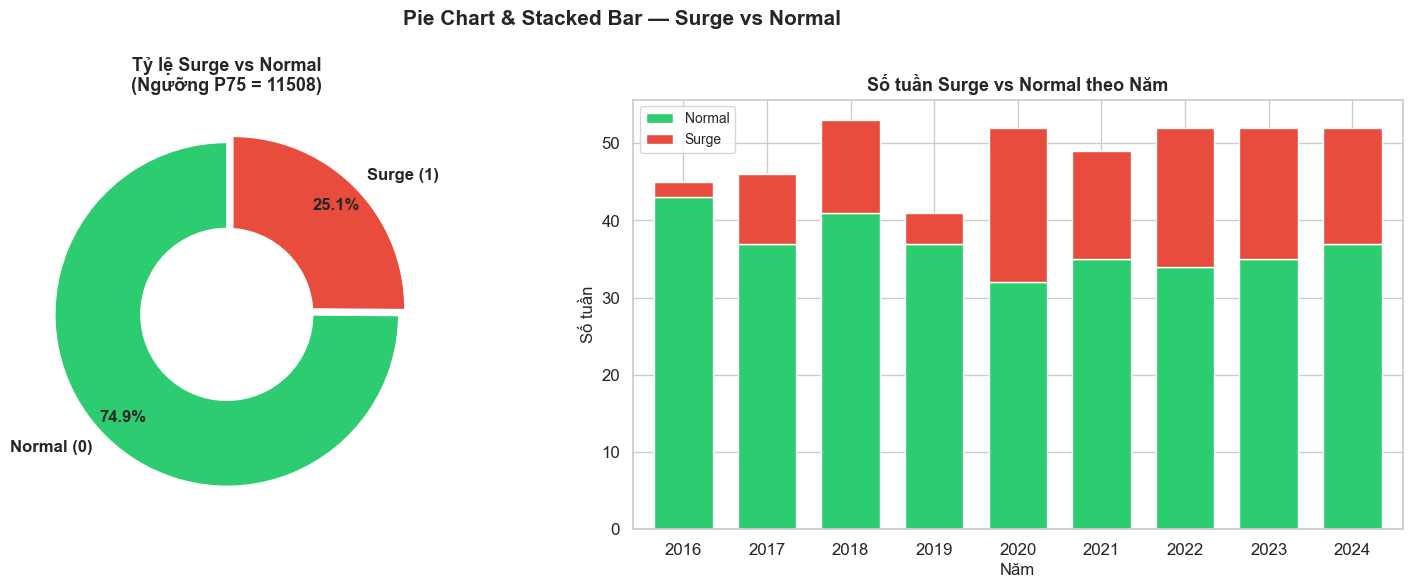

Normal: 331 tuần (74.9%)
Surge:  111 tuần (25.1%)

Surge theo năm:
      Normal  Surge
year               
2016      43      2
2017      37      9
2018      41     12
2019      37      4
2020      32     20
2021      35     14
2022      34     18
2023      35     17
2024      37     15


In [8]:
surge_counts = df['IsSurge'].value_counts().sort_index()
labels = ['Normal (0)', 'Surge (1)']
sizes = [surge_counts[0], surge_counts[1]]
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
wedges, texts, autotexts = axes[0].pie(sizes, labels=labels, colors=colors_pie, explode=explode,
                                        autopct='%1.1f%%', startangle=90, pctdistance=0.85,
                                        textprops={'fontsize': 12, 'fontweight': 'bold'})
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[0].add_artist(centre_circle)
axes[0].set_title(f'Tỷ lệ Surge vs Normal\n(Ngưỡng P75 = {df["deaths_total"].quantile(0.75):.0f})',
                   fontweight='bold', fontsize=13)

# Stacked bar theo năm
yearly_surge = df.groupby(['year', 'IsSurge']).size().unstack(fill_value=0)
yearly_surge.columns = ['Normal', 'Surge']
yearly_surge.plot(kind='bar', stacked=True, color=colors_pie, edgecolor='white',
                  ax=axes[1], width=0.7)
axes[1].set_title('Số tuần Surge vs Normal theo Năm', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Năm', fontsize=12)
axes[1].set_ylabel('Số tuần', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Pie Chart & Stacked Bar — Surge vs Normal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Normal: {sizes[0]} tuần ({sizes[0]/len(df)*100:.1f}%)')
print(f'Surge:  {sizes[1]} tuần ({sizes[1]/len(df)*100:.1f}%)')
print(f'\nSurge theo năm:')
print(yearly_surge.to_string())

## 5.9 Pair Plot — Mối quan hệ giữa tất cả các cặp biến số

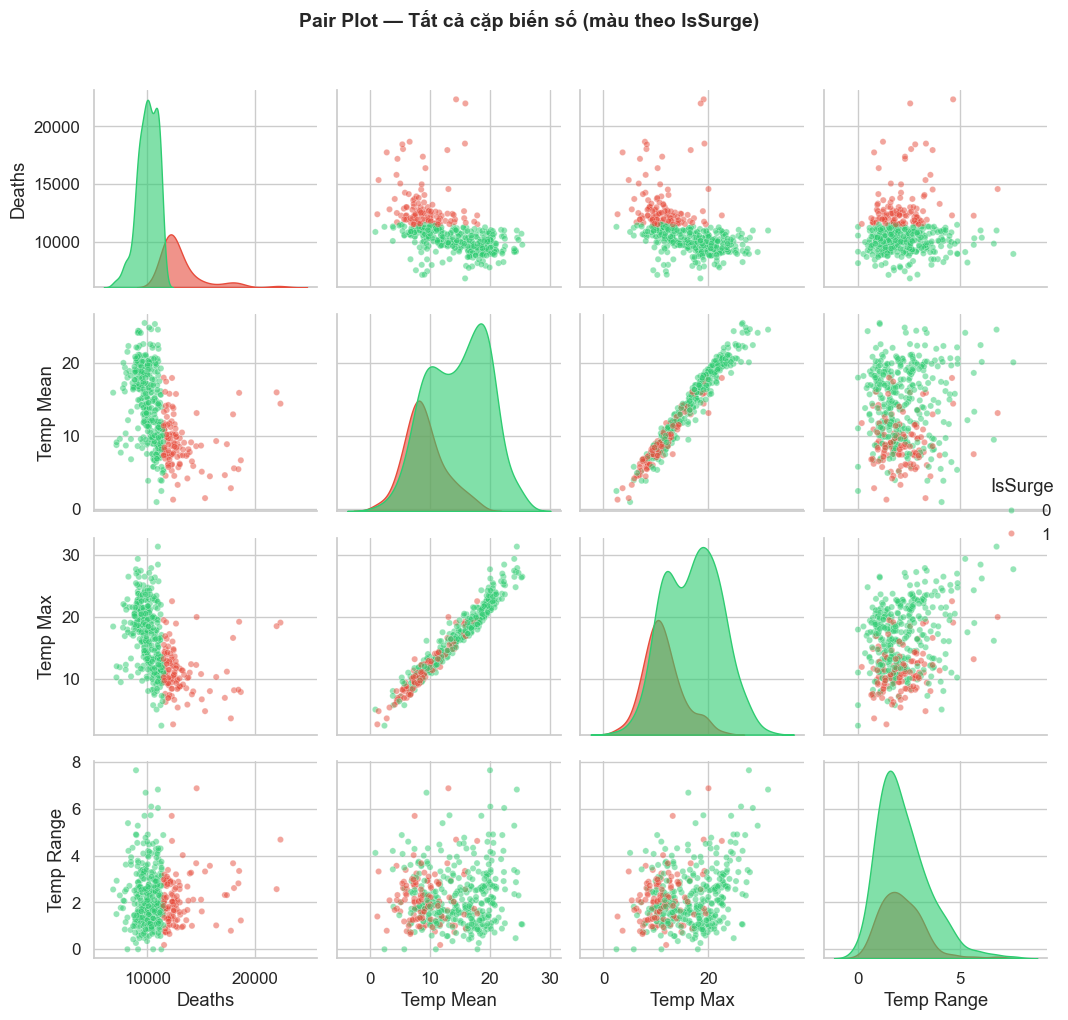

In [9]:
pair_cols = ['deaths_total', 'tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC',
             'temp_range_weekly', 'IsSurge']
pair_labels = {'deaths_total': 'Deaths', 'tasmax_mean_weekly_degC': 'Temp Mean',
               'tasmax_max_weekly_degC': 'Temp Max', 'temp_range_weekly': 'Temp Range',
               'IsSurge': 'IsSurge'}

df_pair = df[pair_cols].rename(columns=pair_labels)

g = sns.pairplot(df_pair, hue='IsSurge', palette={0: '#2ecc71', 1: '#e74c3c'},
                 plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'white', 'linewidth': 0.3},
                 diag_kws={'alpha': 0.6},
                 height=2.5, aspect=1)
g.figure.suptitle('Pair Plot — Tất cả cặp biến số (màu theo IsSurge)', fontweight='bold',
                   fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5.10 Time Series Decomposition — Trend, Seasonality & Residual

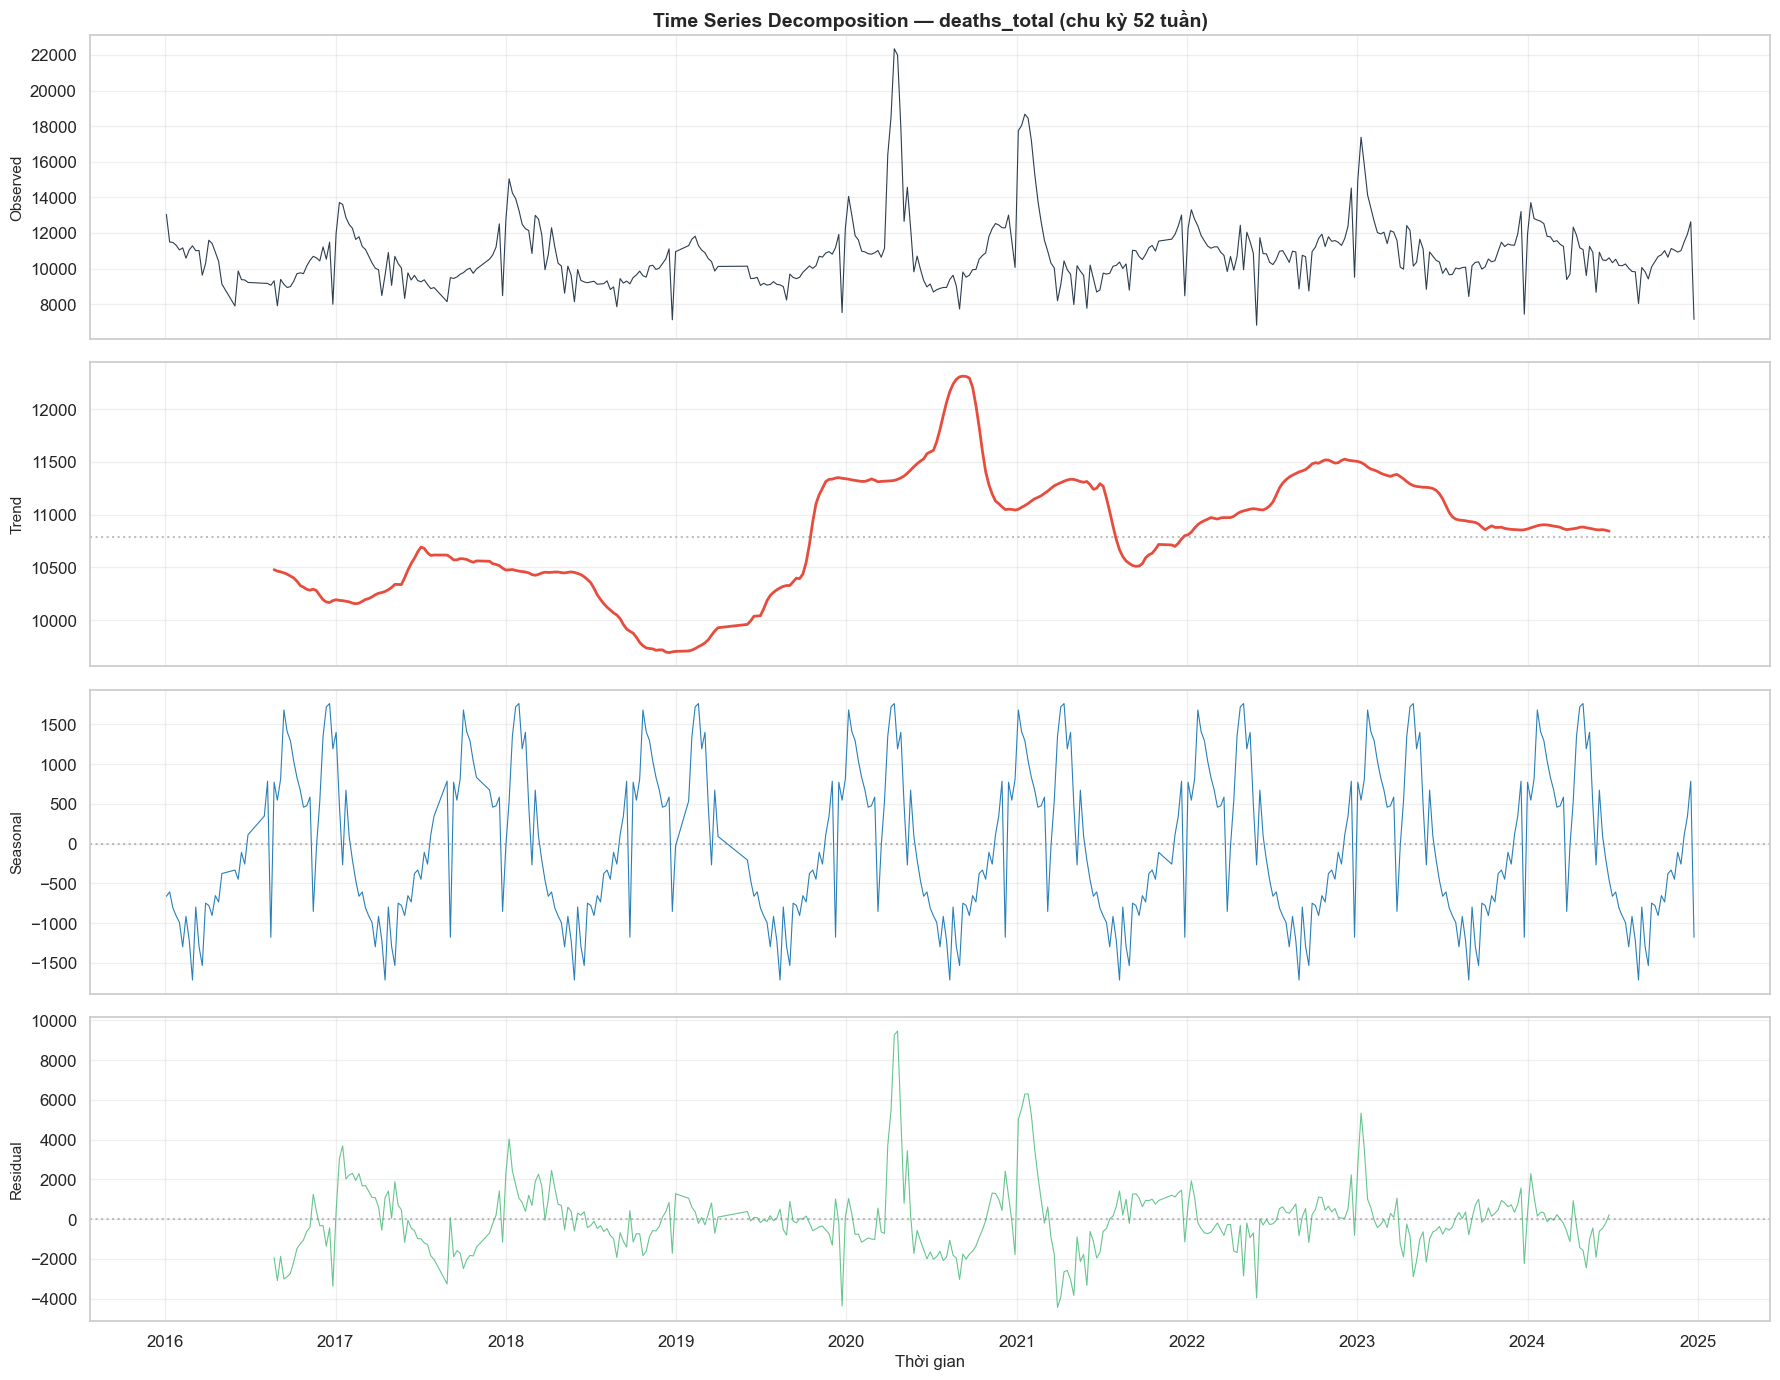

Residual — Mean: -36.0, Std: 1701.9
Residual — Min: -4439, Max: 9469
→ Residual lớn nhất tại COVID: thể hiện sự kiện bất thường không giải thích bằng trend/seasonal


In [10]:
# Decompose deaths_total (chu kỳ 52 tuần = 1 năm)
ts_deaths = df.set_index('week_start_mon')['deaths_total']
decomp = seasonal_decompose(ts_deaths, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)

# Observed
axes[0].plot(decomp.observed, color='#2c3e50', linewidth=0.8)
axes[0].set_ylabel('Observed', fontsize=11)
axes[0].set_title('Time Series Decomposition — deaths_total (chu kỳ 52 tuần)',
                   fontweight='bold', fontsize=14)

# Trend
axes[1].plot(decomp.trend, color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].axhline(ts_deaths.mean(), color='gray', linestyle=':', alpha=0.5)

# Seasonal
axes[2].plot(decomp.seasonal, color='#2980b9', linewidth=0.8)
axes[2].set_ylabel('Seasonal', fontsize=11)
axes[2].axhline(0, color='gray', linestyle=':', alpha=0.5)

# Residual
axes[3].plot(decomp.resid, color='#27ae60', linewidth=0.8, alpha=0.7)
axes[3].set_ylabel('Residual', fontsize=11)
axes[3].axhline(0, color='gray', linestyle=':', alpha=0.5)
axes[3].set_xlabel('Thời gian', fontsize=12)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Phân tích residual
resid = decomp.resid.dropna()
print(f'Residual — Mean: {resid.mean():.1f}, Std: {resid.std():.1f}')
print(f'Residual — Min: {resid.min():.0f}, Max: {resid.max():.0f}')
print(f'→ Residual lớn nhất tại COVID: thể hiện sự kiện bất thường không giải thích bằng trend/seasonal')

## 5.11 Dashboard tương tác — Chọn năm xem chi tiết Thời tiết & Sức khỏe

Sử dụng **Plotly** để tạo dashboard tương tác.

In [11]:
# Dashboard tương tác với Plotly
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=('Số ca tử vong hàng tuần', 'Nhiệt độ TB hàng tuần (°C)')
)

# Thêm trace cho từng năm
years = sorted(df['year'].unique())
colors_plotly = px.colors.qualitative.Set1

for i, year in enumerate(years):
    df_y = df[df['year'] == year]
    color = colors_plotly[i % len(colors_plotly)]
    visible = True  # Tất cả hiện ban đầu

    # Deaths trace
    fig.add_trace(
        go.Scatter(x=df_y['week_start_mon'], y=df_y['deaths_total'],
                   name=f'{year} — Tử vong', mode='lines+markers',
                   line=dict(color=color, width=1.5),
                   marker=dict(size=4), visible=visible,
                   legendgroup=str(year), showlegend=True,
                   hovertemplate=f'Năm {year}<br>Tuần: %{{x|%d/%m/%Y}}<br>Tử vong: %{{y:,.0f}}<extra></extra>'),
        row=1, col=1
    )
    # Temperature trace
    fig.add_trace(
        go.Scatter(x=df_y['week_start_mon'], y=df_y['tasmax_mean_weekly_degC'],
                   name=f'{year} — Nhiệt độ', mode='lines+markers',
                   line=dict(color=color, width=1.5, dash='dot'),
                   marker=dict(size=4), visible=visible,
                   legendgroup=str(year), showlegend=False,
                   hovertemplate=f'Năm {year}<br>Tuần: %{{x|%d/%m/%Y}}<br>Nhiệt độ: %{{y:.1f}}°C<extra></extra>'),
        row=2, col=1
    )

# Tạo buttons để toggle từng năm
buttons = []
n_years = len(years)

# Button "Tất cả"
buttons.append(dict(
    label='Tất cả', method='update',
    args=[{'visible': [True] * (n_years * 2)}]
))

# Button cho từng năm
for i, year in enumerate(years):
    visibility = [False] * (n_years * 2)
    visibility[i * 2] = True      # deaths trace
    visibility[i * 2 + 1] = True  # temp trace
    buttons.append(dict(
        label=str(year), method='update',
        args=[{'visible': visibility}]
    ))

fig.update_layout(
    updatemenus=[dict(
        type='buttons', direction='right',
        x=0.0, xanchor='left', y=1.15, yanchor='top',
        buttons=buttons,
        bgcolor='#f0f0f0', bordercolor='#ccc',
        font=dict(size=11)
    )],
    title=dict(text='Dashboard tương tác — Thời tiết & Sức khỏe theo Năm',
               font=dict(size=16)),
    height=650,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=-0.2, xanchor='center', x=0.5,
                font=dict(size=9)),
    template='plotly_white'
)

fig.update_yaxes(title_text='Số ca tử vong', row=1, col=1)
fig.update_yaxes(title_text='Nhiệt độ (°C)', row=2, col=1)
fig.update_xaxes(title_text='Thời gian', row=2, col=1)

fig.show()
print('→ Bấm nút năm ở góc trên để lọc. Hover để xem chi tiết từng tuần.')

→ Bấm nút năm ở góc trên để lọc. Hover để xem chi tiết từng tuần.


## 5.12 Tổng kết Visualization

In [12]:
print('=' * 70)
print('TỔNG KẾT VISUALIZATION — NOTEBOOK 5')
print('=' * 70)
print('1. Heatmap: Tử vong nghịch biến với nhiệt độ (Pearson r ≈ −0.47)')
print('2. Scatter: Dạng chữ U/J — tử vong cao ở nhiệt độ rất thấp & cao')
print('3. Histogram: deaths_total lệch phải (skew > 2), đuôi dày do COVID')
print('4. Bar Chart: 2020 tử vong cao nhất (COVID), 2022 nóng nhất')
print('5. Violin: Winter tử vong cao nhất, Summer thấp nhất')
print('6. Line Plot: Đỉnh COVID 04/2020 & 01/2021, đỉnh nhiệt 07/2022')
print('7. Pie Chart: ~75% Normal, ~25% Surge')
print('8. Pair Plot: Tất cả biến — Surge tập trung ở vùng lạnh/tử vong cao')
print('9. Decomposition: Trend tăng quanh COVID, Seasonal rõ chu kỳ 52 tuần')
print('10. Dashboard: Tương tác Plotly — chọn năm xem chi tiết')
print('=' * 70)

TỔNG KẾT VISUALIZATION — NOTEBOOK 5
1. Heatmap: Tử vong nghịch biến với nhiệt độ (Pearson r ≈ −0.47)
2. Scatter: Dạng chữ U/J — tử vong cao ở nhiệt độ rất thấp & cao
3. Histogram: deaths_total lệch phải (skew > 2), đuôi dày do COVID
4. Bar Chart: 2020 tử vong cao nhất (COVID), 2022 nóng nhất
5. Violin: Winter tử vong cao nhất, Summer thấp nhất
6. Line Plot: Đỉnh COVID 04/2020 & 01/2021, đỉnh nhiệt 07/2022
7. Pie Chart: ~75% Normal, ~25% Surge
8. Pair Plot: Tất cả biến — Surge tập trung ở vùng lạnh/tử vong cao
9. Decomposition: Trend tăng quanh COVID, Seasonal rõ chu kỳ 52 tuần
10. Dashboard: Tương tác Plotly — chọn năm xem chi tiết


---
*Trước: [4. Data Analysis with Python](./4.%20Data%20Analysis%20with%20Python.ipynb)* | *Tiếp: [6. Regression Analysis](./6.%20Regression%20Analysis.ipynb)*